# Plot polar maps of boreal domain data - MODIS PFT and field plots
Paul Montesano  
Fall 2022 - Aug 2025 
run this notebook in a conda R env

In [1]:
system("conda activate r-with-gdal")

In [2]:
install.packages("mapproj")

Warning message in install.packages("mapproj"):
“installation of package ‘mapproj’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [3]:
#library(aws.s3)
#library(rgdal)
library(raster)
library(tidyverse)
library(dplyr)
library(grid)
library(gridExtra)
library(RColorBrewer)
library(data.table)

library(fs)
library(sf)
#library(rgdal)


#library(rgeos)
library(mapproj)
#library(rgee)
#library(viridis)
#library(wesanderson)
library(scales)
library(tools)
#library(patchwork)

library(rnaturalearth)
library(rnaturalearthdata)
#library(feather)

#conda install -c conda-forge r-rnaturalearth r-rnaturalearthdata r-mapproj r-rgeos r-viridis r-wesanderson r-patchwork r-aws.s3 r-feather r-rockchalk

Loading required package: sp

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks raster::extract()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ dplyr::select()  masks raster::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, 

## Set output figure dir.

In [5]:
OUT_FIGURE_DIR = '/projects/my-public-bucket/boreal_AGB/paper_figs'
dir.create(OUT_FIGURE_DIR)

Warning message in dir.create(OUT_FIGURE_DIR):
“'/projects/my-public-bucket/boreal_AGB/paper_figs' already exists”


### Mapping functions and vars

In [6]:
source('/projects/code/3dsi/boreal_map_functions.R') 

[1] "MAAP"
[1] "MAAP"


In [7]:
# # Circ map new: trying to combine the best of the sf and sp approaches
# DO_MAP_BOREAL_SP <- function( MAP_EXTENT = extent(-180,180,45,90), xlim=NULL, ylim=NULL, rotate_map=0, proj_name = 'azequalarea', LAYER_LIST=NULL, 
#                              BOREAL_SHP_FN = '/projects/my-public-bucket/misc_files/Ecoregions2017_boreal_m.shp'){
#   #
#   # Map with a polar projection
#   #
  
#   # Color scale help
#   #https://biostats.w.uib.no/color-scale-for-continuous-variables/
  
#   #source(path("C:\\Users\\pmontesa\\Google Drive\\Work\\R","plot_functions.R"))
#   # Shapefiles
  
#   world <- crop(ne_countries(scale = "medium", returnclass = "sp"), MAP_EXTENT)
  
#   # WWF
#   #boreal <- shp_fort_join("D:\\databank\\wwf\\arc\\wwf_circumboreal_Dissolve.shp", MAP_EXTENT, REPROJECT = TRUE)
#   # TerraPulse
#   boreal <- shp_fort_join(boreal_shp_fn, MAP_EXTENT, REPROJECT = TRUE)
  
#   map_list_base = list(
    
#     geom_polygon(data = fortify(world), aes(x = long, y = lat, group = group), fill="grey90", color=NA),
#     geom_polygon(data = boreal, aes(x = long, y = lat, group = group), color=NA, fill="grey70"))
    
#   map_list_top = list(
    
#     geom_polygon(data = fortify(world), aes(x = long, y = lat, group = group), fill=NA, color="black", size=0.1 ),
    
#     theme_minimal() , 
#     theme(axis.text = element_blank(), axis.title = element_blank() ) ,
    
#     #geom_polygon(data = fortify(continents.df_stereo), aes(x = long, y = lat, group = group), fill = NULL, colour = "black", size=0.25) +
#     #scale_color_distiller(palette = "Greens", direction = 1, name = "%"),
#     #scale_color_manual(values = COLOR_PAL, name = map_str) ,
#     guides(guide = guide_legend(direction = "horizontal", nrow=1, label.position = "bottom", title.position = "bottom") ) ,
#     theme(legend.position="top",
#           legend.title = element_text(size=9),
#           #       legend.direction  = 'vertical',
#           legend.key.width  = unit(1.0, "cm"),
#           legend.key.height = unit(.25, "cm")  )
#   )
  
#   if(is.null(LAYER_LIST)){
#     map_list = list(
#       map_list_base,
#       map_list_top
#     )
#   }else{
#     map_list = list(
#       map_list_base,
#       LAYER_LIST,
#       map_list_top
#     )
#   }
  
#   p_map = ggplot() + map_list +
#     #coord_map_stereo_list(proj_name = proj_name, min_lat = MAP_EXTENT[3], rotation=rotate_map, xlim = xlim, ylim = ylim)
#     coord_map_stereo_list(proj_name = proj_name, min_lat = MAP_EXTENT[3], rotation=rotate_map)
  
#   if(FALSE){
#     out_plot_fn = paste0("D:/projects/3dsi/plots/map_boreal_",proj_name,"_", format(Sys.time(), "_%Y%m%d"),'.png')
#     print(out_plot_fn)
#     ggsave(plot = p_map ,
#            file = out_plot_fn,
#            device = 'png', dpi = 300, width = 5, height = 5)
#   }
#   #print(p_map)
#   return(p_map)
  
# }

# coord_map_stereo_list <- function(proj_name = "stereo", rotation = 0, min_lat = 50, xlims=NULL, ylims=NULL, LABEL_SIZE=3){ 
  
#   # Defines the x axes required
#   lat_lines = seq(min_lat+10, 80, by = 10)
#   lat_labs = paste0(seq(min_lat+10, 80, by = 10), "\u00B0N")
  
#   lon_lines = seq(0, 330, by = 30)
#   lon_labs = c("0", paste0(seq(30, 150, by = 30), "°E"), "180", rev(paste0(seq(30, 150, by = 30), "°W")))
  
  
#   return(list(
#     # Convert to polar coordinates
#     coord_map(proj_name, orientation = c(90, 0, rotation, xlims=xlims, ylims=ylims)), #"ortho""
#     scale_y_continuous(breaks = seq(45, 90, by = 5), labels = NULL),
    
#     # Removes Axes and labels
#     scale_x_continuous(breaks = NULL),
#     xlab(""),
#     ylab(""),
    
#     # Adds axes
#     # Latitude
#     geom_hline(aes(yintercept = lat_lines), size = 0.25, color = "grey80", linetype = "dotted"),
#     # Outer circular border
#     geom_hline(aes(yintercept = min_lat), size = 0.25), #1
#     # Longitude
#     geom_vline(aes(xintercept = lon_lines), size = 0.25, color = "grey80", linetype = "dotted"),
#     #geom_segment(aes(y = 45, yend = 85, x = x_lines, xend = x_lines), linetype = "dotted") +
    
#     # Adds labels
#     #geom_text(aes(x = 0, y = lat_lines, hjust = 0.5, label = lat_labs)),
#     geom_label(aes(x = 0, y = lat_lines, label = lat_labs), label.size = NA, size=LABEL_SIZE, color = "black", fill="white", label.padding=unit(0.1,"lines")),
#     #geom_text(aes(x = lon_lines, y = min_lat-3, hjust = 0.5, vjust = 0.5, label = lon_labs), size = 2.5), #hjust = 0.5
#     # min-3 so lon labels are centered over outer line
#     geom_label(aes(x = lon_lines, y = min_lat-3, label = lon_labs), label.size = NA,  hjust='inward', vjust='inward', size = LABEL_SIZE, color = "black", fill="white", label.padding=unit(0.1,"lines")),  #y = min_lat-3 why used to be this?
    
#     ##guides(fill=FALSE)+
    
#     # Change theme to remove axes and ticks
#     theme(panel.background = element_blank(),
#           #panel.grid = element_line(size = 0.25, linetype = 'dotted', colour = "grey50"),
#           axis.ticks=element_blank())
#     #,
#     #labs(caption = "Source: circ_tte_map.Rmd")
#   ))
# }  
# shp_fort_join = function(shapefile_fn, ext, REPROJECT=FALSE){

#   shp_name = tools::file_path_sans_ext(basename(shapefile_fn))
#   shp = readOGR(shapefile_fn, layer = shp_name)
#   # Test this, so you can read in geojson and gpkg
#   #shp = sf::st_read(shapefile_fn)

#   if(REPROJECT){
#       # Shapefile reprojection to geog
#       geog_proj4 = '+proj=longlat +datum=WGS84 +no_defs +ellps=WGS84 +towgs84=0,0,0'
#       shp <- spTransform(shp, geog_proj4)
#   }

#   shp <- crop(shp, ext)
  
#   #Get attributes, fortify data, and merge attributes to data
#   tbl = shp@data
#   tbl$id <- rownames(tbl)
#   shp.df <- ggplot2::fortify(shp, id = "id")
  
#   return(plyr::join(shp.df, tbl, by = "id"))
# }

# gridCreate<-function(shp, res,proj_out, buffer=10000){
  
#   if (!is.null(buffer)){
#     shp<-buffer(shp, width=buffer)
#   }
#   ext <- floor(extent(shp))
#   rr <- raster(ext, res=res)
#   rr <- rasterize(shp, rr, field=1)
#   rr[!is.na(rr[])]<-1:length(rr[!is.na(rr[])])
#   grid<-rasterToPolygons(rr)
#   crs(grid)<-projection(shp)
#   if (!proj_out==projection(shp)){
#     grid<-spTransform(grid,CRS(proj_out))
#   }
#   return(grid)  
# }



In [8]:
crs_canalb = "+proj=aea +lat_0=40 +lon_0=180 +lat_1=50 +lat_2=70 +x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs"
crs_albers = "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=180 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"
crs_gcs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"

# Map Boreal EXTENT, ATL08, and Biomass

#### Read boreal extent, read tiles, then clip tiles to boreal extent

In [9]:
wwf_circ_dis_fn

/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp

In [10]:
boreal_shp_fn = '/projects/my-public-bucket/misc_files/Ecoregions2017_boreal_m.shp'
boreal_shp_fn = '/projects/shared-buckets/montesano/databank/arc/wwf_circumboreal_Dissolve.gpkg'
#boreal_shp_fn = '/projects/shared-buckets/montesano/databank/arc/boreal.shp'
#boreal_shp_fn = wwf_circ_dis_fn
boreal = st_read(boreal_shp_fn)
boreal_albers<-spTransform(sf:::as_Spatial(boreal),CRS(crs_albers))

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/shared-buckets/montesano/databank/arc/wwf_circumboreal_Dissolve.gpkg' 
  using driver `GPKG'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


In [11]:
if(ADAPT){
    boreal_tile_index_path = '/home/pmontesa/pmontesa/userfs02/projects/above_icesat2/boreal_tiles/boreal_tiles_v004.gpkg'
    }else{
    boreal_tile_index_path = '/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg'
    }
#boreal_tile_index_path = '/projects/shared-buckets/nathanmthomas/boreal_tiles_v003.gpkg'
# boreal_tiles_clip = st_intersection(
#                                 st_read(boreal_tile_index_path) %>% st_transform(crs="+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"), 
#                                 boreal)#%>% as.data.frame()

#### Get only the boreal tile nums that coincide with the boreal extent

In [12]:
# #head(boreal_tiles_clip%>% as.data.frame())
# boreal_tile_num_list = boreal_tiles_clip %>% as.data.frame() %>% dplyr::select(tile_num) %>% as.list()
# boreal_tile_num_list = unlist(boreal_tile_num_list[[1]])
# length(boreal_tile_num_list)

## Map showing boreal tile extent

In [13]:
ext = raster::extent(-180,180,40,90)

In [14]:
boreal_tiles_gcs = shp_fort_join(boreal_tile_index_path, ext, REPROJECT=TRUE)

[1] "Using sf and coercing to Spatial object..."
Reading layer `boreal_tiles_v004' from data source 
  `/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg' 
  using driver `GPKG'
Simple feature collection with 5344 features and 4 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -6111478 ymin: 1233304 xmax: 6308522 ymax: 10323300
Projected CRS: unnamed


Warning message:
“`fortify(<SpatialPolygonsDataFrame>)` was deprecated in ggplot2 3.4.4.
ℹ Please migrate to sf.”
Regions defined for each Polygons


### Read in boreal AGB training (field) plots

In [17]:
boreal_training = as_Spatial( st_as_sf(read.csv("/projects/shared-buckets/minord/data/above/boreal_plot_density.csv"), coords = c('longitude', 'latitude') , crs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"))%>% 
            as.data.frame()
names(boreal_training)[1] = "value"
names(boreal_training)[length(names(boreal_training))-1] = "x"
names(boreal_training)[length(names(boreal_training))] = "y"

geom_field_list = list(
        geom_point(data = boreal_training, aes(x = x, y = y, size=n), shape=21, color='black'),
        scale_radius(labels = c(1,50,150,350), breaks = c(1,50,150,340)),
        guides(size=guide_legend(title="# of simulated\nICESat-2 footprints", title.position = "top", label.position = "bottom", keywidth = unit(.5, "cm"), keyheight = unit(.25, "cm"), ncol=4))
)

In [22]:
smry_sim_icesat2_PFT = data.frame(pft_name=c('Deciduous Broadleaf trees','Deciduous Needleleaf trees', 'Evergreen Needleleaf trees', 'Grass/Shrub/Wet/Savanna','Mixed forests'),
                                  #pft_code=c('DBT','DNT','ENT','GSWS','MF'),
                                  num_sim_icesat2=c(1131,15,5533,181,124))
smry_sim_icesat2_PFT

pft_name,pft_code,num_sim_icesat2
<chr>,<chr>,<dbl>
Deciduous Broadleaf trees,DBT,1131
Deciduous Needleleaf trees,DNT,15
Evergreen Needleleaf trees,ENT,5533
Grass/Shrub/Wet/Savanna,GSWS,181
Mixed forests,MF,124


[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


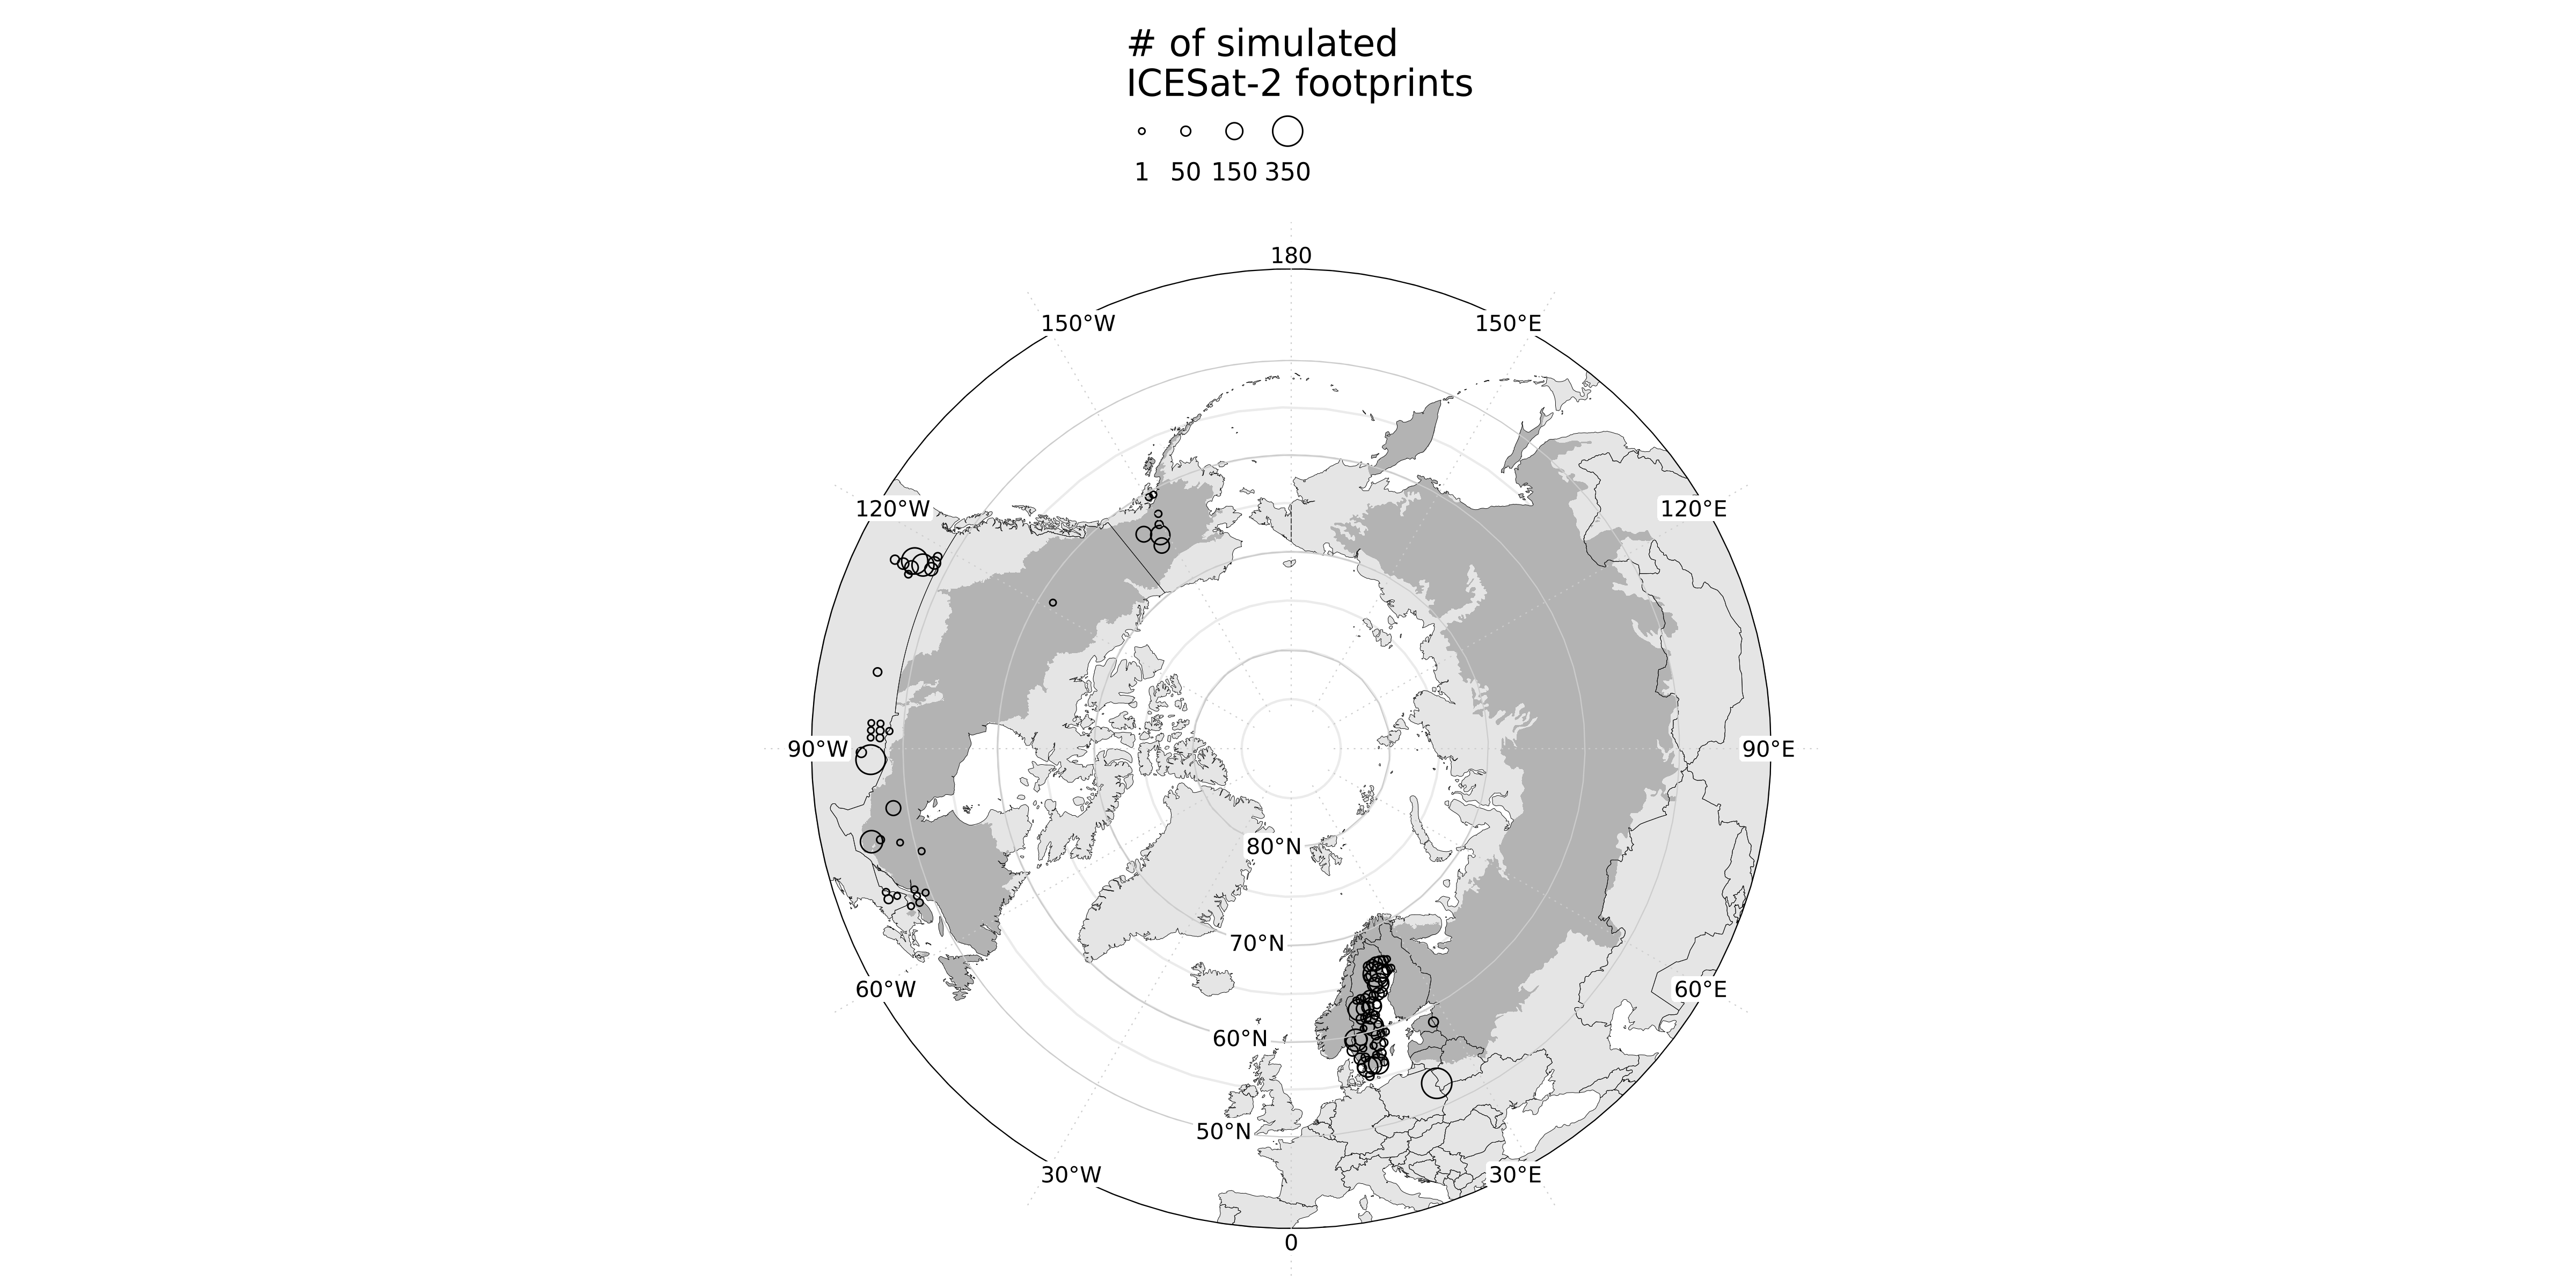

In [89]:
options(repr.plot.width = 16, repr.plot.height =8, repr.plot.res = 300)

DO_MAP_BOREAL_SP(MAP_EXTENT=ext,  
                         BOREAL_SHP_FN = wwf_circ_dis_fn,
                         LAYER_LIST = geom_field_list
                        ) + 
        theme(
            legend.title=element_text(size=rel(1.5)), # 1.25
            legend.text=element_text(size=rel(1)), #0.75
            plot.caption = element_text(size = 7)
        ) 

## Map MODIS PFT and training plots
This is the MODIS Type 1 PFT, which I think we decided to use because it was already included in ATL08.  
For this figure, I made a coarsened version that sampled the PFT every 0.1 degrees: shared-buckets/minord/data/above/modis_type1_pft_coarsened.csv



In [23]:
modis_pft = sample_frac(read.csv("/projects/shared-buckets/minord/data/above/modis_type1_pft_coarsened.csv"), 0.5)
levels(factor(modis_pft$pft_modis))

modis_pft_sf = st_as_sf(modis_pft, coords = c('longitude', 'latitude') , crs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs")# %>% st_transform(crs_canalb)

[1] "Closed Shrubland"           "Deciduous Broadleaf trees" 
 [3] "Deciduous Needleleaf trees" "Evergreen Broadleaf trees" 
 [5] "Evergreen Needleleaf trees" "Grasslands"                
 [7] "Mixed forests"              "Open Shrublands"           
 [9] "Permanent wetlands"         "Savannas"                  
[11] "Woody savannas"

In [24]:
modis_pft_boreal_sf = st_intersection(modis_pft_sf, 
                                    st_as_sf(boreal) %>% select(REALM) %>% st_transform(crs = crs_gcs) 
                                   )

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


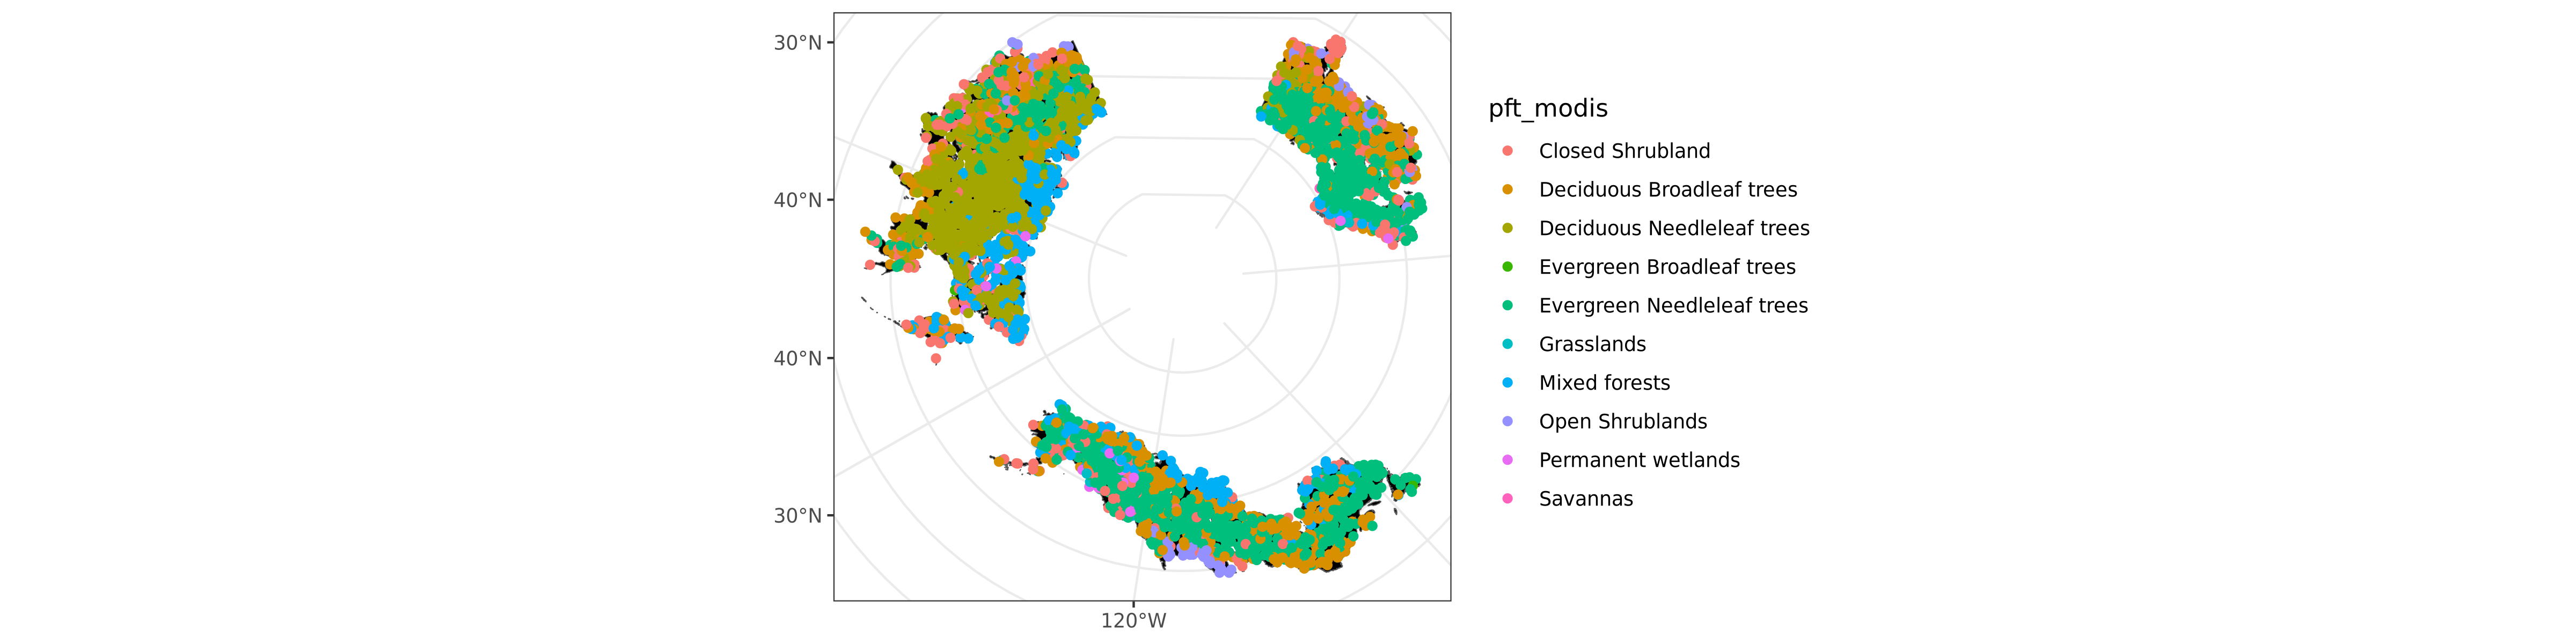

In [39]:
options(repr.plot.width = 16, repr.plot.height =4, repr.plot.res = 300)

ggplot() + 
    geom_sf(data=boreal, fill='black') + 
    geom_sf(data=sample_frac(modis_pft_boreal_sf, 0.025) %>% drop_na(), aes(color=pft_modis) ) +
    theme_bw()

In [25]:
modis_pft_geo_p =  as_Spatial( modis_pft_boreal_sf) %>% 
            as.data.frame()
names(modis_pft_geo_p)[1] = "value"
names(modis_pft_geo_p)[length(names(modis_pft_geo_p))-1] = "x"
names(modis_pft_geo_p)[length(names(modis_pft_geo_p))] = "y"
class(modis_pft_geo_p)

[1] "data.frame"

In [26]:
modis_pft_geo_p$pft_modis = factor(modis_pft_geo_p$pft_modis)

In [27]:
levels(factor(modis_pft_geo_p$pft_modis) )

[1] "Closed Shrubland"           "Deciduous Broadleaf trees" 
 [3] "Deciduous Needleleaf trees" "Evergreen Broadleaf trees" 
 [5] "Evergreen Needleleaf trees" "Grasslands"                
 [7] "Mixed forests"              "Open Shrublands"           
 [9] "Permanent wetlands"         "Savannas"                  
[11] "Woody savannas"

In [28]:

#modis_pft_geo_p$pft_modis = factor(modis_pft_geo_p$pft_modis, levels = gsub(" trees", " ", levels(factor(modis_pft_geo_p$pft_modis) )))


In [29]:
levels(modis_pft_geo_p$pft_modis)

[1] "Closed Shrubland"           "Deciduous Broadleaf trees" 
 [3] "Deciduous Needleleaf trees" "Evergreen Broadleaf trees" 
 [5] "Evergreen Needleleaf trees" "Grasslands"                
 [7] "Mixed forests"              "Open Shrublands"           
 [9] "Permanent wetlands"         "Savannas"                  
[11] "Woody savannas"

In [30]:
#levels_new = c('Closed Shrubland','Deciduous Broadleaf\nforests','Deciduous Needleleaf\nforests','Evergreen Broadleaf\nforests','Evergreen Needleleaf\nforests','Grasslands','Mixed forests','Open Shrublands','Permanent wetlands','Savannas''Woody savannas')

In [31]:
head(modis_pft_geo_p %>% drop_na())

,value,date,pft_modis,REALM,x,y
,<int>,<chr>,<fct>,<chr>,<dbl>,<dbl>
1,1,2017-01-01,Evergreen Needleleaf trees,NA,-69.4,52.5
2,1,2017-01-01,Evergreen Needleleaf trees,NA,-93.7,53.5
3,1,2017-01-01,Evergreen Needleleaf trees,NA,-126.3,60.1
4,1,2017-01-01,Evergreen Needleleaf trees,NA,-125.7,60.8
5,1,2017-01-01,Evergreen Needleleaf trees,NA,-78.2,50.6
6,1,2017-01-01,Evergreen Needleleaf trees,NA,-142.0,65.8


In [32]:
dim(modis_pft_geo_p  %>% drop_na())

[1] 147634      6

In [52]:
# Create a named vector that maps PFT names to labels with counts
pft_labels_with_counts <- setNames(
    paste0(smry_sim_icesat2_PFT$pft_name, "\n(n=", smry_sim_icesat2_PFT$num_sim_icesat2, ")"),
    smry_sim_icesat2_PFT$pft_name
)
pft_labels_with_counts

Deciduous Broadleaf trees             Deciduous Needleleaf trees 
 "Deciduous Broadleaf trees\n(n=1131)"   "Deciduous Needleleaf trees\n(n=15)" 
            Evergreen Needleleaf trees                Grass/Shrub/Wet/Savanna 
"Evergreen Needleleaf trees\n(n=5533)"     "Grass/Shrub/Wet/Savanna\n(n=181)" 
                         Mixed forests 
              "Mixed forests\n(n=124)"

In [62]:
map_extent = extent(-180, 180, 45, 90)
min_lat = map_extent[3]

year_agb = '2020'
VERSION = 'v2.1'
dim(modis_pft_geo_p)

PFT_COLOR_DICT = c(
                'Evergreen Broadleaf trees' = 'red', #'#5aae61',
                'Deciduous Broadleaf trees' = '#5aae61',
                'Deciduous Needleleaf trees'= '#a6dba0',
                'Evergreen Needleleaf trees' ='#1b7837',#'#542608',
                'Grass/Shrub/Wet/Savanna' =   '#e6ab02',
                'Mixed forests' =             '#718a6e'
    )

#['Deciduous broadleaf trees' = '#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d']

# PFT_COLOR_DICT = c('Closed Shrubland'='#ebd775', 'Open Shrublands'='#ebd775', 'Grasslands'='#ebd775', 
# 'Savannas'='#ebd775', 'Evergreen Needleleaf trees'='#542608', 'Deciduous Broadleaf trees'='#34a327',
# 'Evergreen Broadleaf trees'='#91f783', 'Woody savannas'='#ebd775', 'Permanent wetlands'='#ebd775', 
#                    'Mixed forests'='#718a6e', 'Deciduous Needleleaf trees'='#542608', 'NA'='#c3c5c9')

# Case needs a character col
modis_pft_geo_p$pft_modis = as.character(modis_pft_geo_p$pft_modis)
GSWS_classname = 'Grass/Shrub/Wet/Savanna'
modis_pft_geo_p = modis_pft_geo_p %>%
    dplyr::mutate(pft_modis_adj = case_when(pft_modis == 'Closed Shrubland' ~   GSWS_classname, 
                                            pft_modis == 'Open Shrubland' ~     GSWS_classname, 
                                            pft_modis == 'Grasslands' ~         GSWS_classname, 
                                            pft_modis == 'Woody savannas' ~     GSWS_classname, 
                                            pft_modis == 'Permanent wetlands' ~ GSWS_classname,  
                                                   TRUE ~ pft_modis))
# Put to factor
modis_pft_geo_p$pft_modis_adj = factor(modis_pft_geo_p$pft_modis_adj)

theme_and_labs = list(
    theme_classic(),
    labs(#title="Circumpolar boreal plant functional type",
        #subtitle = paste0("c. ",year_agb," 30 m resolution, provisional","\nData sources: ICESat-2, Landsat-8, Copernicus DEM"),
         #caption = paste0("# obs: ", NUM_ATL08_OBS, "\n# obs (night): ", NUM_ATL08_NIGHT_OBS)
         #caption = 'Arctic Boreal Vulnerability Experiment (ABoVE)\nNASA Goddard Space Flight Center\nU. of Maryland Dept. Geographical Sciences'
    )
)



[1] 152772      7

[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/shared-buckets/montesano/databank/arc/wwf_circumboreal_Dissolve.gpkg' 
  using driver `GPKG'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


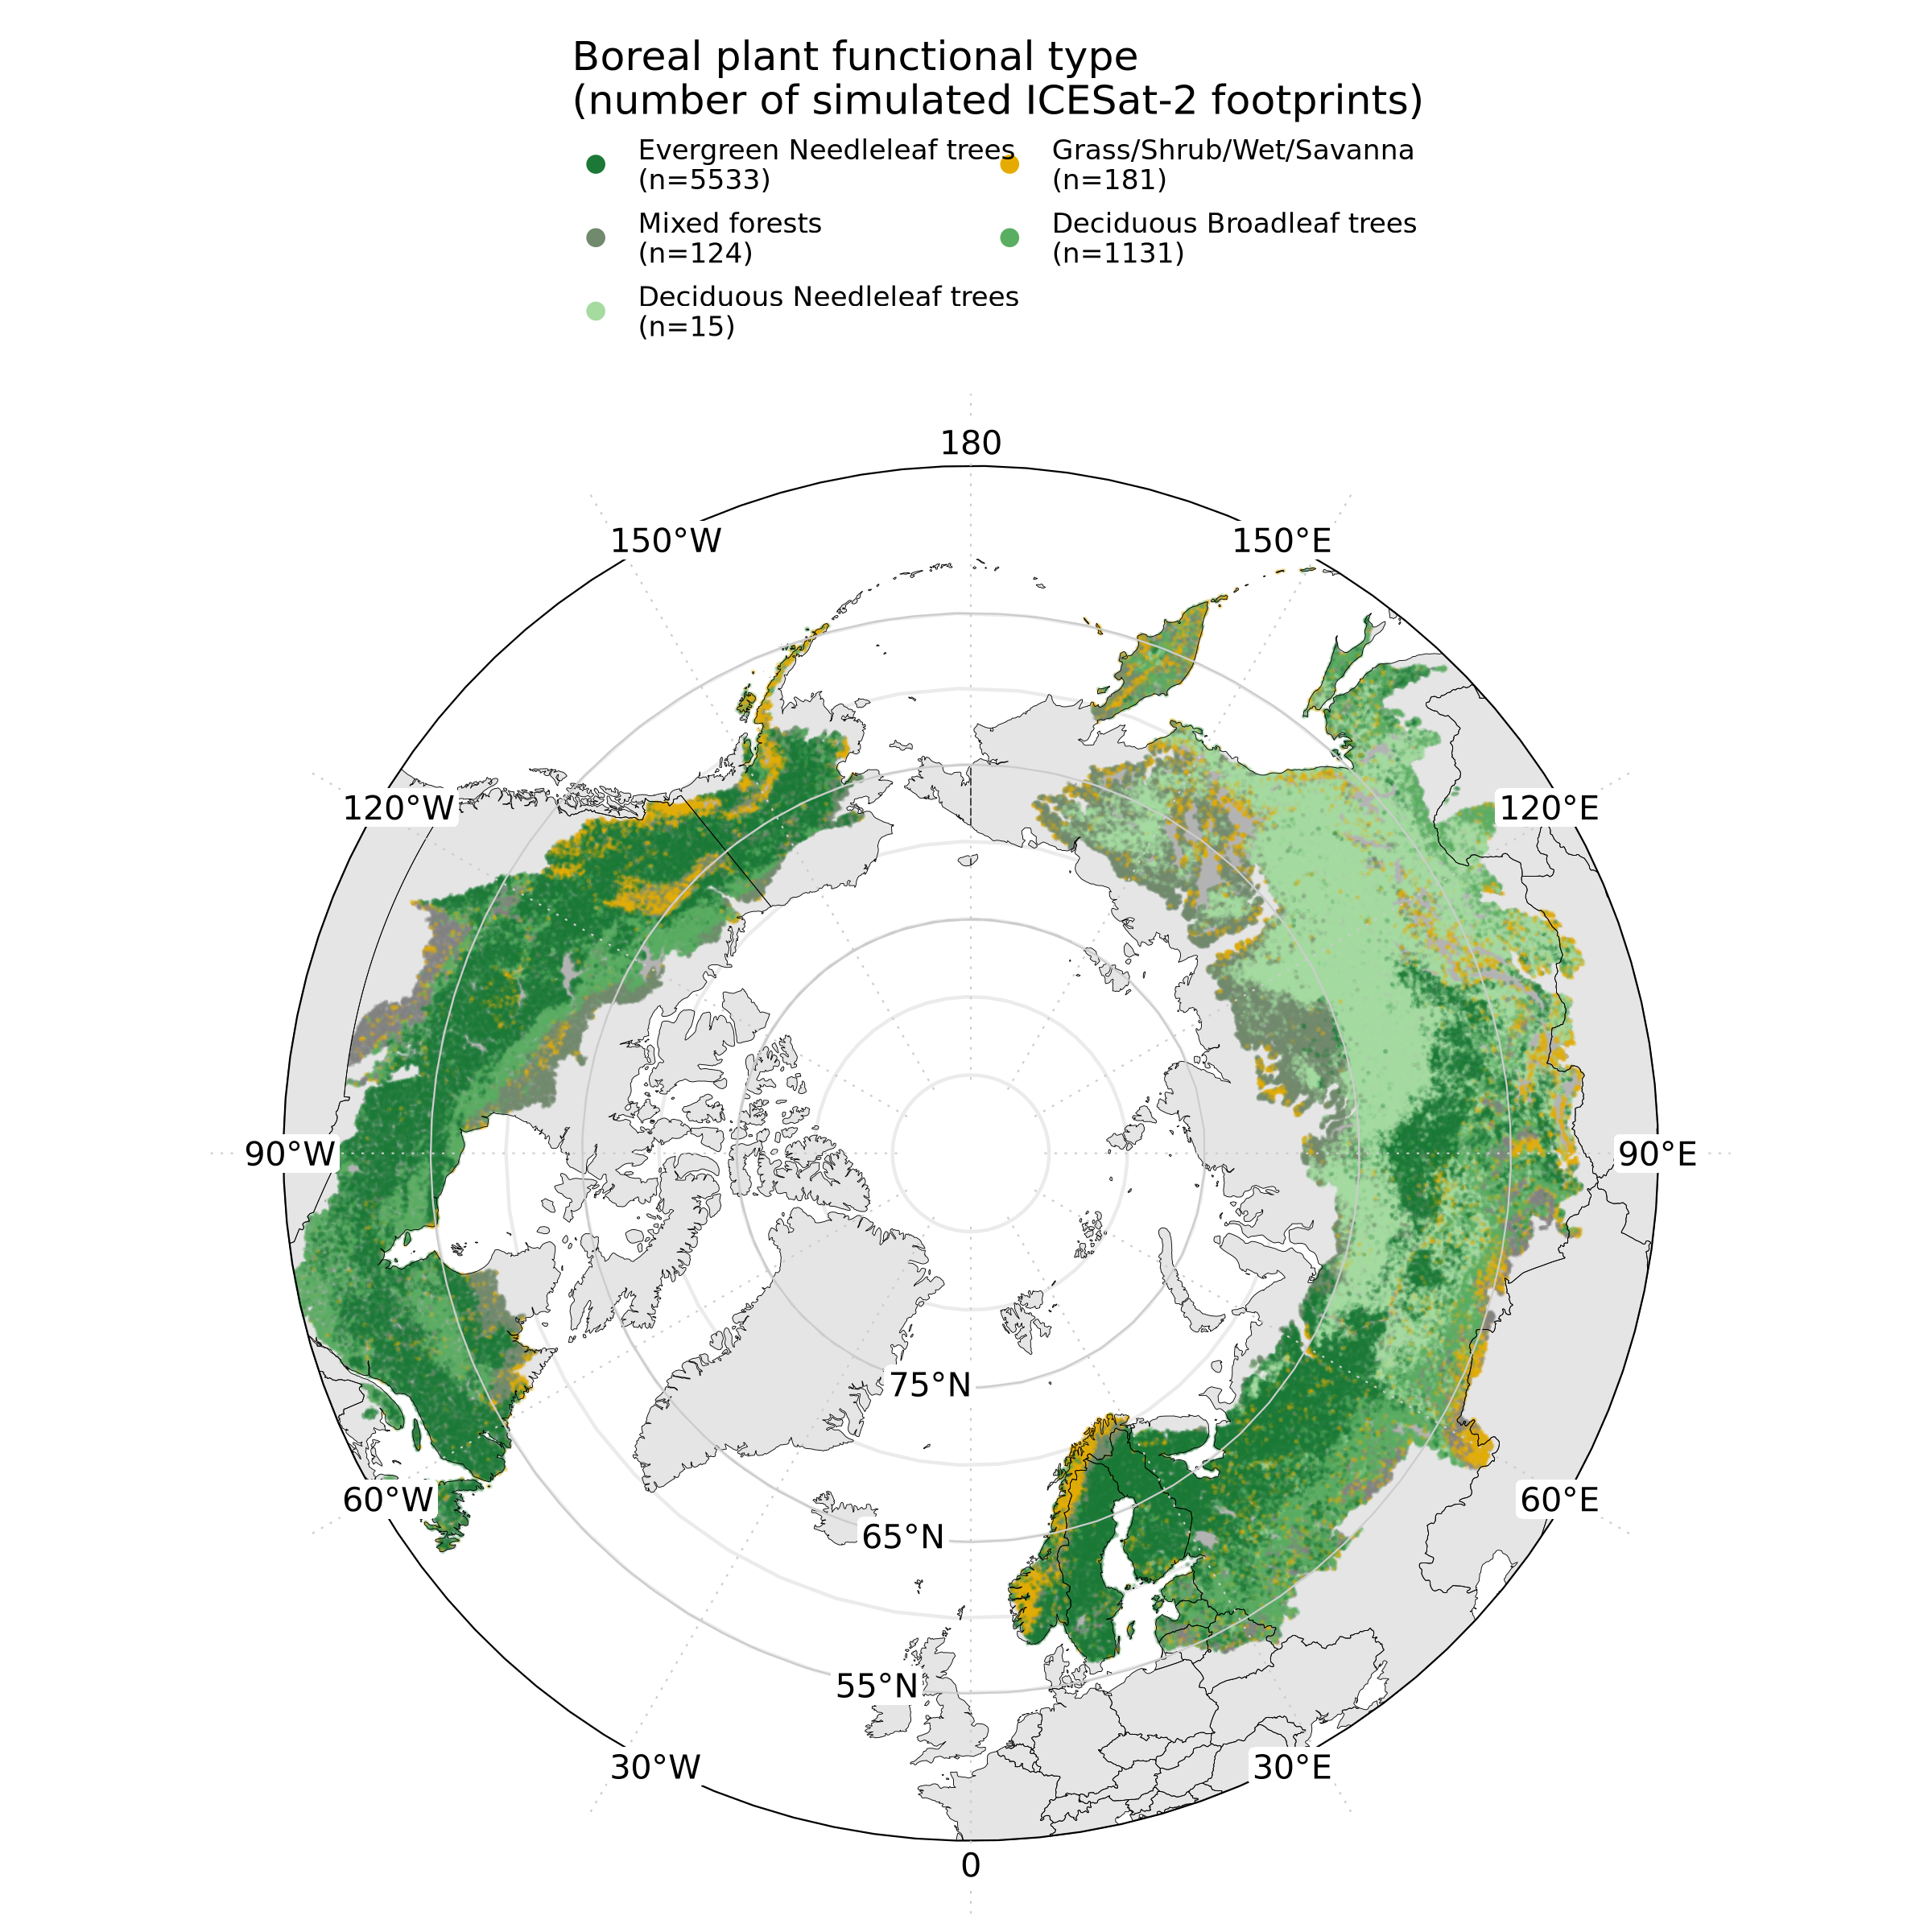

In [69]:
pft_layer_list = list( 
    geom_point(data = sample_frac(modis_pft_geo_p, 1) %>% 
               dplyr::filter(y > min_lat,
                            pft_modis_adj != 'Evergreen Broadleaf trees' # these shouldnt appear in domain
                            ) %>%
               drop_na() %>%
               mutate(pft_modis_adj = factor(pft_modis_adj, 
                                   levels = unique(pft_modis_adj)))  # Only keep present levels
               
               , aes(x = x, y = y, color = pft_modis_adj), size = 0.1, alpha = 0.25),
    #scale_color_gradientn(limits = c(0,MAX_AGB), breaks = seq(0,MAX_AGB,50), colours = viridis(10), name = expression(Mg~ha^{-1})),
    theme_and_labs,
    #scale_color_viridis_d(option = "magma",
    #                       guide = guide_legend(override.aes = list(size = 3) ) )
    scale_color_manual(values = PFT_COLOR_DICT)

    #theme(legend.text=element_text(size=rel(0.25)))
    #guides(color=guide_legend(title="Boreal plant functional type", title.position = "top", label.position = "bottom", keywidth = unit(.5, "cm"), keyheight = unit(.5, "cm"), nrow=1))+
    
)

m_pft = DO_MAP_BOREAL_SP(MAP_EXTENT=map_extent, BOREAL_SHP_FN = boreal_shp_fn, LAYER_LIST = pft_layer_list) +
    # scale_color_manual(values = PFT_COLOR_DICT) +
    scale_color_manual(values = PFT_COLOR_DICT, 
                   labels = pft_labels_with_counts) +  # Add the labels parameter here
    guides(color = guide_legend(
        title="Boreal plant functional type\n(number of simulated ICESat-2 footprints)", title.position = "top", label.position = "right", 
        #legend.text=element_text(size=rel(0.0025)),
        override.aes = list(size = 2, alpha=1) ,
        keywidth = unit(.5, "cm"), keyheight = unit(.5, "cm"), ncol=2
    ) )+
    theme(
        legend.text=element_text(size=rel(0.75)), 
        legend.title = element_text(size = rel(1.1)), 
        legend.position = 'top',
        legend.spacing.y = unit(0.1, "mm"),    # Vertical spacing between legend items
        legend.spacing.x = unit(0.2, "mm"),    # Horizontal spacing between legend items
        legend.key.height = unit(0.8, "mm"),   # Height of legend keys
        legend.key.width = unit(0.8, "mm"),     # Width of legend keys
        plot.background = element_rect(fill = "white", color = NA),    # Add this
        panel.background = element_rect(fill = "white", color = NA)    # Add this
    )

m_pft

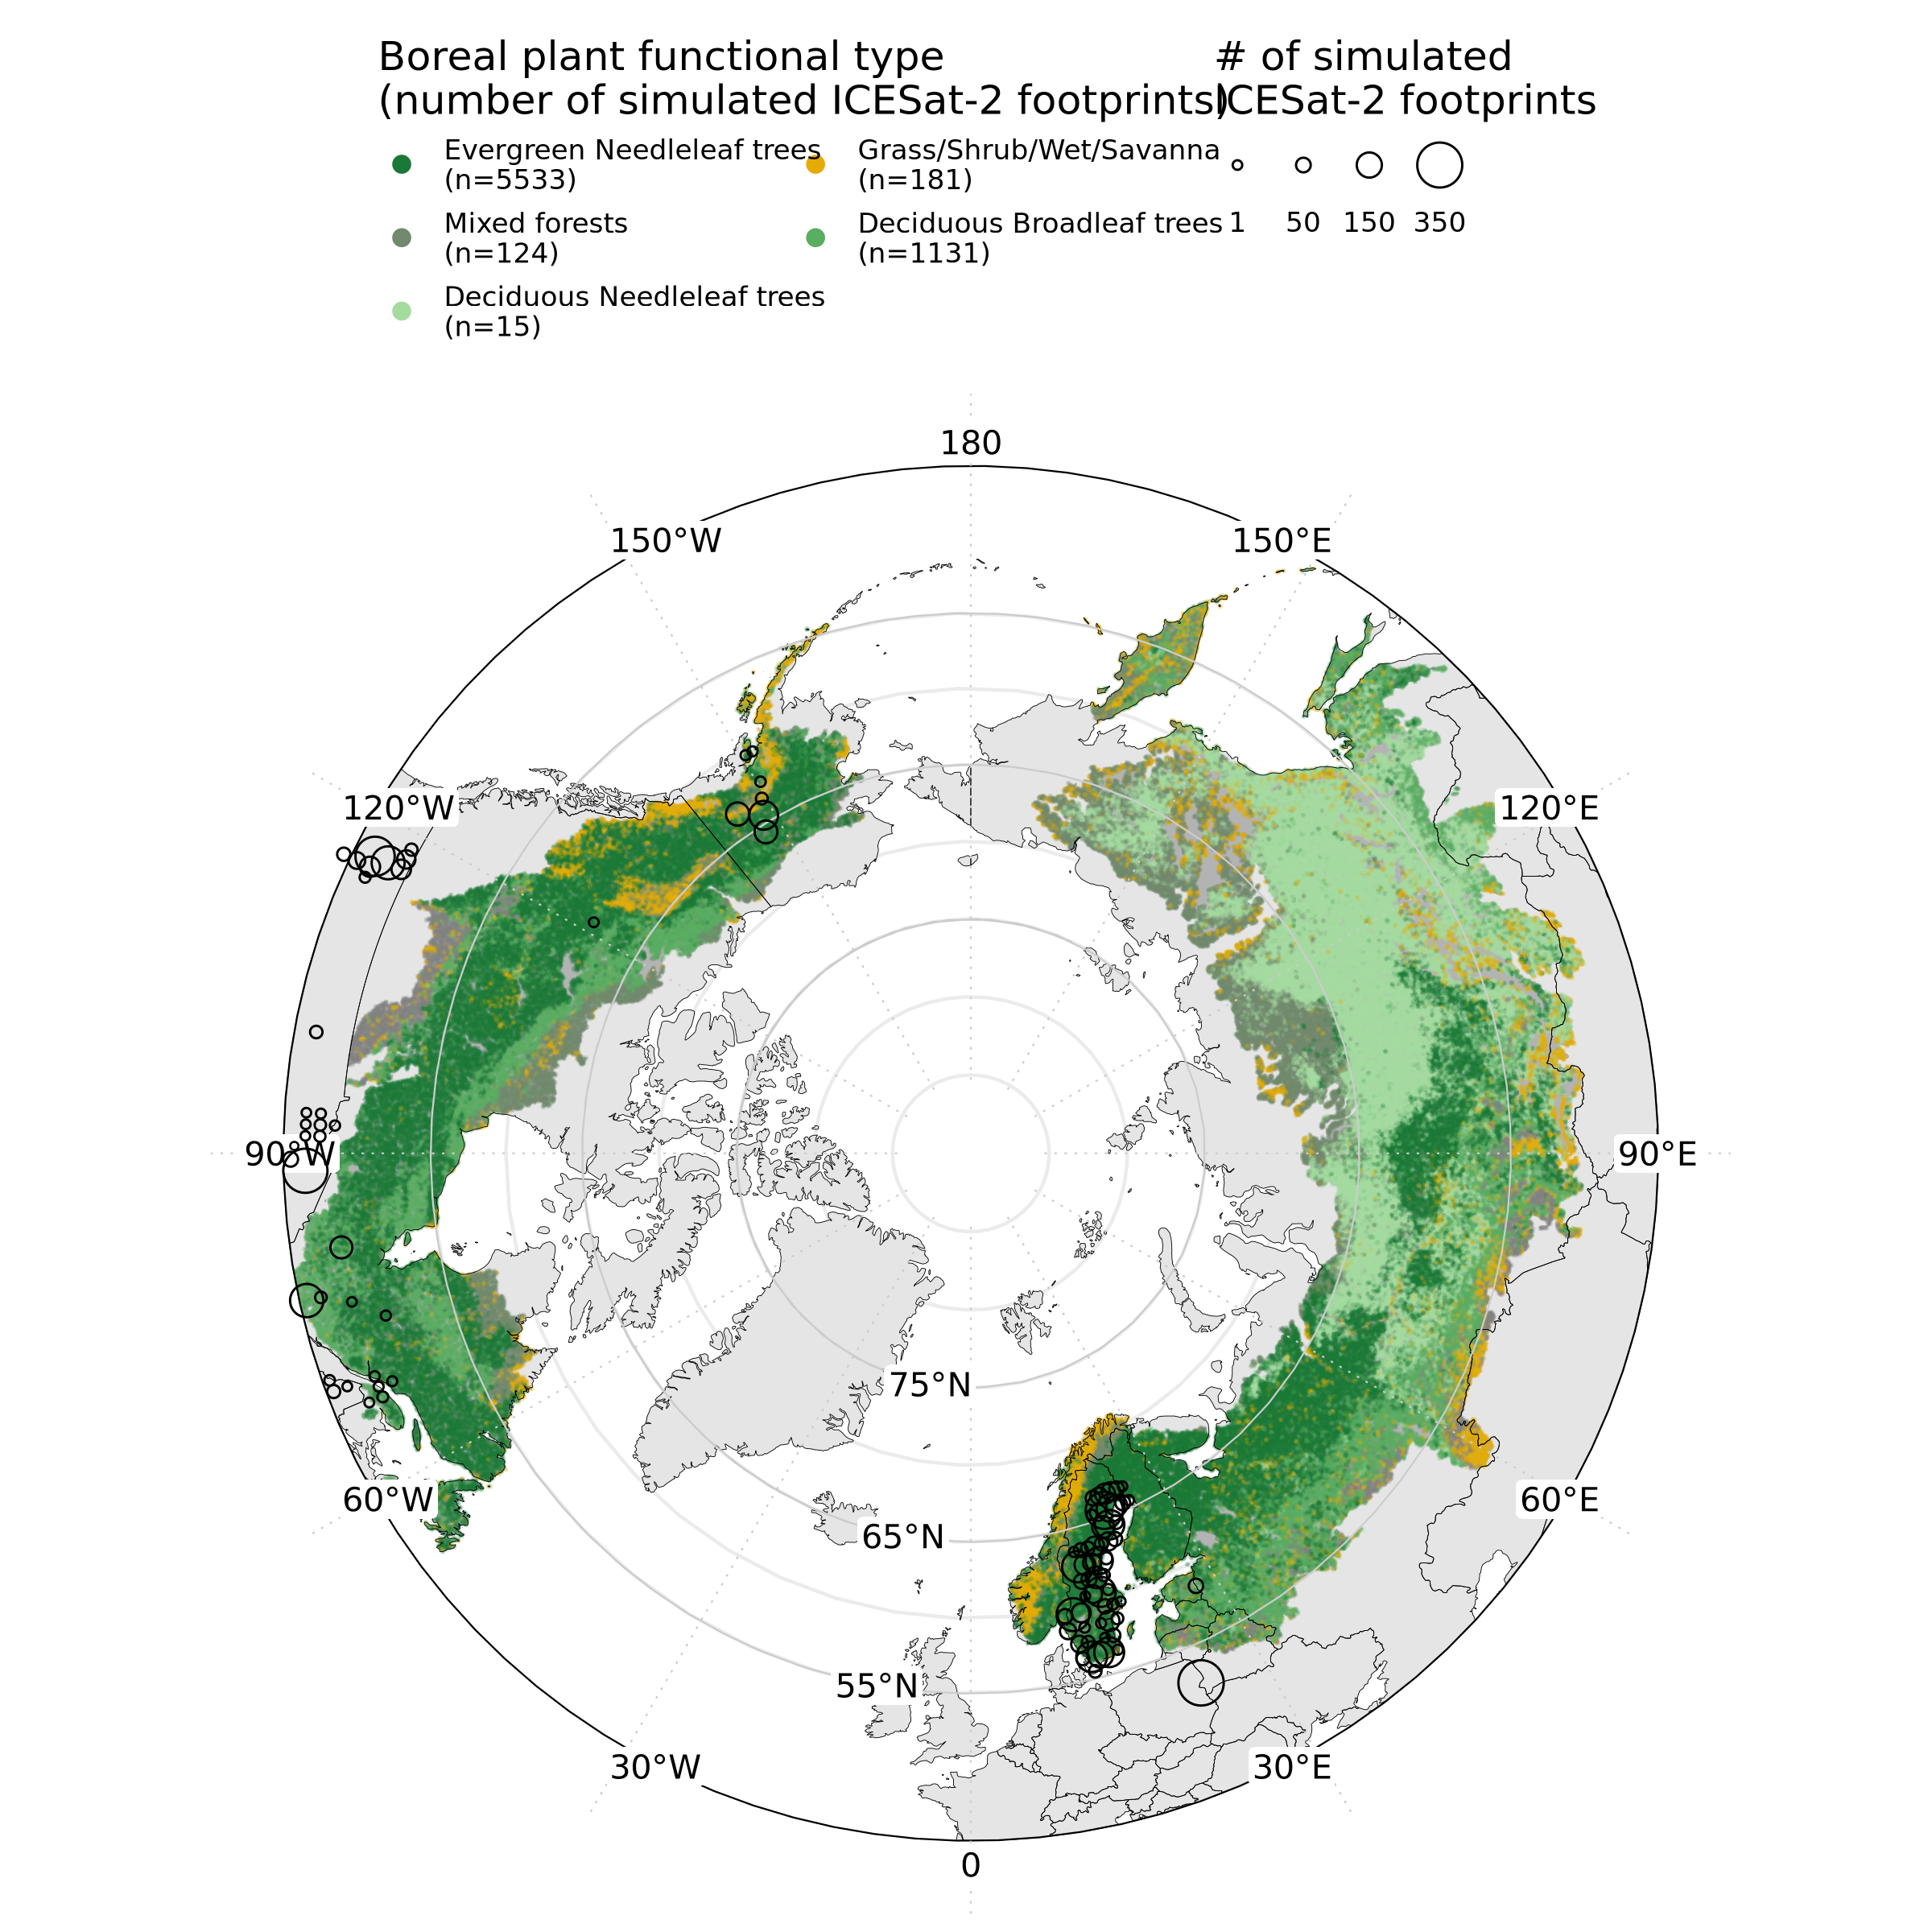

In [70]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 300)

# Adding the boreal training field plots
m_pft = m_pft + geom_field_list
m_pft

## Export figure: MODIS PFT & training plots

In [71]:
EXPORT_PNG_PDF <- function(m_plot_figure, OUT_FIGURE_DIR, DATA_NAME_STEM, VAR, EXPORT_TIME_STR=format(Sys.time(), "_%Y%m%d"), FIG_DIMS=c(8,16), TYPE='map'){
    
    for(OUT_TYPE in c('png', 'pdf')){
        
        map_fn = path(OUT_FIGURE_DIR, paste0(TYPE,"_",DATA_NAME_STEM,"_", VAR, EXPORT_TIME_STR,".", OUT_TYPE))
        print(map_fn)
        
        ggsave(plot = m_plot_figure,
               file = map_fn,
               device = OUT_TYPE, dpi = 300, width=FIG_DIMS[1], height=FIG_DIMS[2], bg='white')
    }
}

In [72]:
EXPORT_MAPS_PNG_PDF(m_pft, OUT_FIGURE_DIR, 'BOREAL_MODISPFT', 'field_plots', EXPORT_TIME_STR=format(Sys.time(), "_%Y%m%d"), FIG_DIMS=c(8,8))

/projects/my-public-bucket/boreal_AGB/paper_figs/map_BOREAL_MODISPFT_field_plots_20260225.png
/projects/my-public-bucket/boreal_AGB/paper_figs/map_BOREAL_MODISPFT_field_plots_20260225.pdf
